## Sprint 6 - Projeto 

## Introdução

Este projeto tem como objetivo identificar padrões que determinam o sucesso de jogos eletrônicos, utilizando dados históricos de vendas, avaliações e características como gênero, plataforma e classificação etária.

A análise será utilizada para apoiar decisões estratégicas de marketing para o ano de 2017, considerando que estamos em dezembro de 2016.
Serão aplicadas técnicas de limpeza de dados, análise exploratória, visualizações e testes estatísticos para extrair insights relevantes para o negócio.



### Etapa 1 - Carregamento e Inspeção

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carregamento do dataset
df = pd.read_csv('/datasets/games.csv')

# Visualização geral da estrutura
df.info()

# Primeiras linhas para inspeção visual
df.head()

# Estatísticas descritivas iniciais
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


Nesta primeira etapa foi realizado o carregamento do conjunto de dados e a inspeção inicial das informações disponíveis.

Foram verificados:

- Tipos de dados das colunas;
- Presença de valores ausentes;
- Estatísticas descritivas;
- Estrutura geral do dataset.

Essa etapa permite identificar inconsistências e definir estratégias de tratamento dos dados.

### Análise detalhada de valores ausentes

=== ANÁLISE DE VALORES AUSENTES ===

Quantidade de valores ausentes por coluna:
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
total_sales           0
dtype: int64

Percentual de valores ausentes por coluna:
                 Valores_Ausentes  Percentual
name                            2    0.011965
platform                        0    0.000000
year_of_release               269    1.609333
genre                           2    0.011965
na_sales                        0    0.000000
eu_sales                        0    0.000000
jp_sales                        0    0.000000
other_sales                     0    0.000000
critic_score                 8578   51.319174
user_score                   9125   54.591684
rating                       6766   40.478612
total_sales            

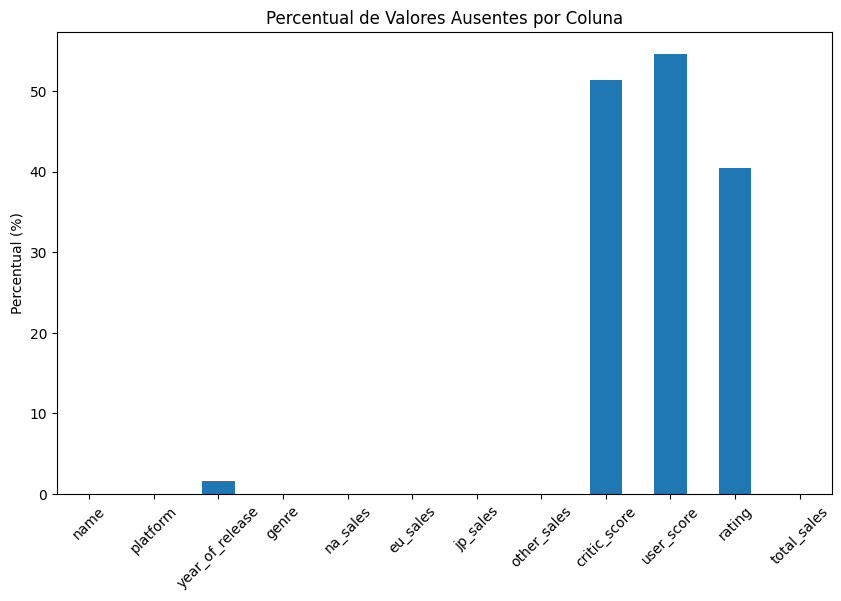

In [10]:
print("=== ANÁLISE DE VALORES AUSENTES ===")
print("\nQuantidade de valores ausentes por coluna:")
missing_values = df.isnull().sum()
print(missing_values)

print("\nPercentual de valores ausentes por coluna:")
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    'Valores_Ausentes': missing_values,
    'Percentual': missing_percent
})
print(missing_summary)

# Visualização dos valores ausentes
plt.figure(figsize=(10, 6))
missing_percent.plot(kind='bar')
plt.title('Percentual de Valores Ausentes por Coluna')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=45)
plt.show()

### Análise do impacto dos valores ausentes nas colunas principais

In [12]:
print("=== IMPACTO DOS VALORES AUSENTES ===")
print(f"Total de registros: {len(df)}")
print(f"Registros com Year_of_Release ausente: {df['year_of_release'].isnull().sum()}")
print(f"Registros com Critic_Score ausente: {df['critic_score'].isnull().sum()}")
print(f"Registros com User_Score ausente: {df['user_score'].isnull().sum()}")
print(f"Registros com Rating ausente: {df['rating'].isnull().sum()}")

=== IMPACTO DOS VALORES AUSENTES ===
Total de registros: 16715
Registros com Year_of_Release ausente: 269
Registros com Critic_Score ausente: 8578
Registros com User_Score ausente: 9125
Registros com Rating ausente: 6766


## Etapa 2 - Preparação dos dados

In [2]:
df.columns = df.columns.str.lower()

Os nomes das colunas foram convertidos para letras minúsculas para manter consistência e evitar erros durante a manipulação.

In [3]:
## Padronizar colunas
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce')
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

**Conversão de Tipos**

Algumas colunas foram convertidas para formato numérico para permitir análises estatísticas adequadas:

- **year_of_release**
- **critic_score**
- **user_score**

As colunas **year_of_release**, **critic_score** e **user_score** foram convertidas para formato numérico.

In [4]:
## Criar coluna de vendas globais
df['total_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)

### Análise do Número de Jogos por Ano

O gráfico mostra a quantidade de jogos lançados anualmente ao longo do período analisado.
Observa-se um crescimento significativo no número de lançamentos até determinado momento, seguido por estabilização e posterior redução. Essa variação pode estar associada à transição entre gerações de consoles e mudanças no mercado.
É importante considerar que os dados de 2016 podem estar incompletos, o que pode impactar a comparação com anos anteriores.
Essa análise ajuda a entender a evolução do mercado e reforça a necessidade de focar em períodos mais recentes para projeções futuras.

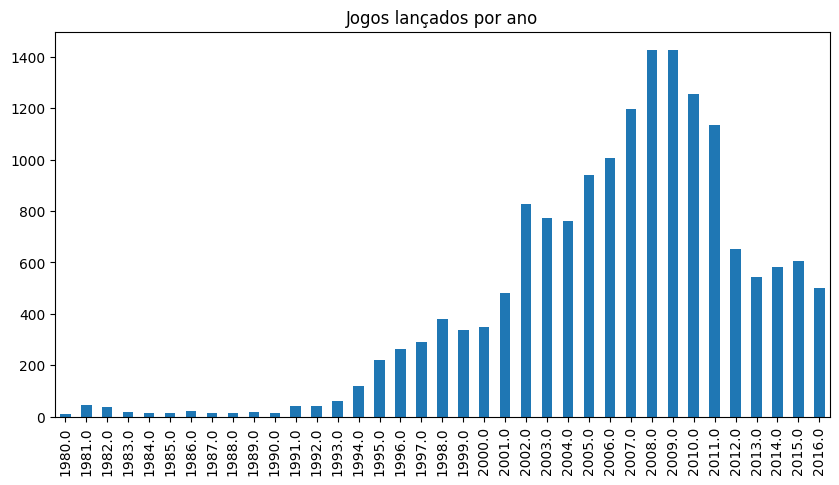

In [5]:
df['year_of_release'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))
plt.title('Jogos lançados por ano')
plt.show()

### Plataformas mais vendidas
A análise das vendas totais por plataforma permite identificar quais consoles lideraram o mercado no período recente.
Observa-se que algumas plataformas concentram grande parte das vendas globais, enquanto outras apresentam participação reduzida.
Esse comportamento reflete o ciclo de vida dos consoles, no qual novas plataformas substituem gradualmente as antigas.

In [6]:
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales.head()


platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
Name: total_sales, dtype: float64

### Distribuição de Vendas por Plataforma (Período Recente)

O boxplot apresenta a distribuição das vendas globais por plataforma considerando os jogos lançados a partir de 2010.
É possível observar diferenças significativas entre as plataformas em relação à mediana das vendas e à dispersão dos dados.
A presença de diversos outliers indica que o mercado é fortemente influenciado por poucos títulos de grande sucesso comercial.
Além disso, algumas plataformas apresentam maior consistência nas vendas, enquanto outras dependem de poucos jogos com alto desempenho.
Essa análise ajuda a identificar quais plataformas possuem maior potencial comercial no período recente.

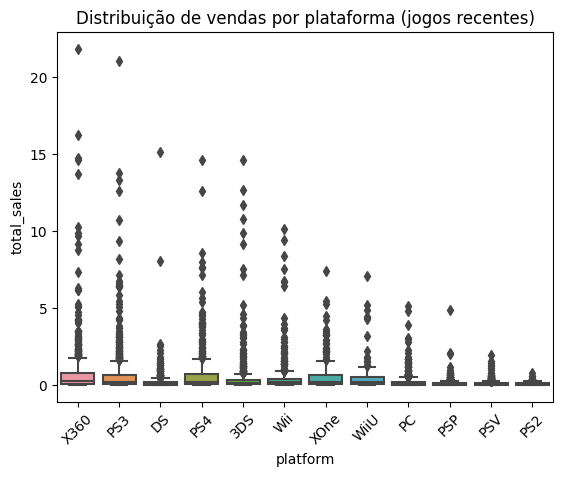

In [7]:

# Definir jogos "recentes" (exemplo: após 2010)
recent_df = df[df['year_of_release'] >= 2010]

# Agora o boxplot funcionará
sns.boxplot(data=recent_df, x='platform', y='total_sales')
plt.xticks(rotation=45)
plt.title('Distribuição de vendas por plataforma (jogos recentes)')
plt.show()

### Relação entre Avaliações Críticas e Vendas (PS4)

O gráfico de dispersão apresenta a relação entre a pontuação dos críticos (`critic_score`) e as vendas globais (`total_sales`) para jogos da plataforma PS4.
Observa-se que existe uma tendência positiva, indicando que jogos com avaliações mais altas tendem a apresentar maiores vendas. No entanto, a dispersão dos pontos demonstra que essa relação não é perfeita.
O coeficiente de correlação calculado confirma a intensidade dessa relação. Caso o valor esteja próximo de 0, a correlação é fraca. Se estiver mais próximo de 1, a relação é moderada ou forte.
Isso indica que, embora a avaliação crítica influencie o desempenho comercial, ela não é o único fator determinante para o sucesso de um jogo.

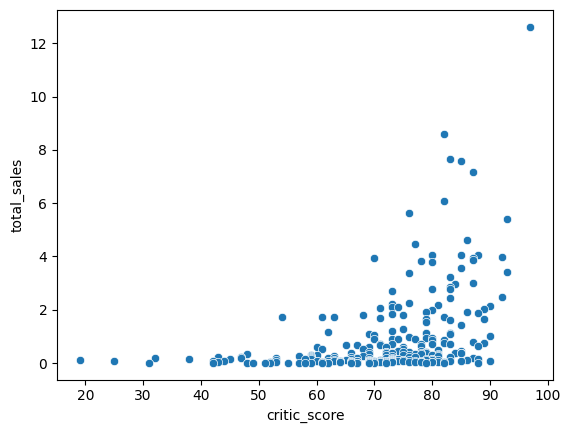

,critic_score,total_sales
critic_score,1.000000,0.406568
total_sales,0.406568,1.000000


In [8]:
# Correlação nota vs vendas (PS4)
ps4 = recent_df[recent_df['platform'] == 'PS4']

sns.scatterplot(data=ps4, x='critic_score', y='total_sales')
plt.show()

ps4[['critic_score', 'total_sales']].corr()


### Distribuição de Vendas por Gênero

O gráfico apresenta o total de vendas globais por gênero no período selecionado.
Observa-se que alguns gêneros concentram maior volume de vendas, indicando maior popularidade e potencial comercial. Gêneros no topo do ranking demonstram forte aceitação do público no período recente.
Por outro lado, gêneros com menores volumes de vendas podem representar nichos específicos ou menor apelo comercial global.
Essa análise é fundamental para direcionar campanhas publicitárias, priorizando gêneros com maior desempenho e maior probabilidade de sucesso no mercado.

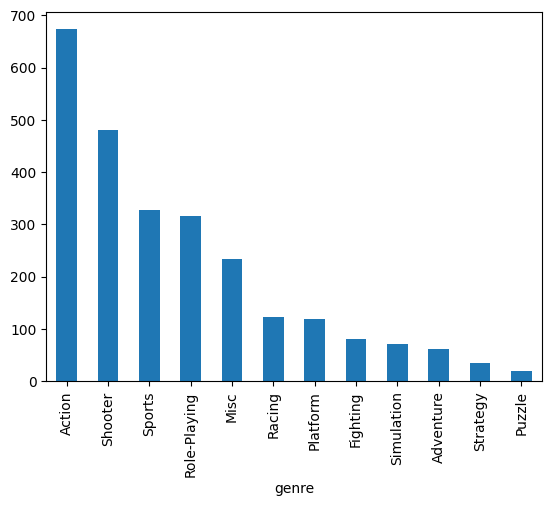

In [9]:
## Genêros
genre_sales = recent_df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales.plot(kind='bar')
plt.show()

## Etapa 4 - Perfil de Usuário – América do Norte (NA)
A análise das vendas por plataforma na América do Norte indica que o Xbox 360 lidera o mercado no período recente, seguido por PS3 e Wii.
Esse resultado demonstra forte preferência regional por consoles da Microsoft e Sony, com destaque histórico para a geração anterior de consoles.
Observa-se também que plataformas mais recentes, como PS4 e Xbox One, começam a ganhar espaço, refletindo a transição para a nova geração.
Essa distribuição reforça a importância de considerar preferências regionais no planejamento de campanhas publicitárias.

In [21]:
recent_df.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head()

platform
X360    334.18
PS3     229.25
Wii     121.20
PS4     108.74
XOne     93.12
Name: na_sales, dtype: float64

### Influência da Classificação ESRB – América do Norte
A análise das vendas por classificação etária demonstra que determinadas categorias concentram maior volume de vendas na região.
Classificações como Mature (M) e Teen (T) costumam apresentar forte desempenho na América do Norte, indicando predominância de público adolescente e adulto jovem.
Isso sugere que jogos com conteúdo voltado para essas faixas etárias possuem maior potencial comercial no mercado norte-americano.

In [22]:
## ESRB por região
recent_df.groupby('rating')['na_sales'].sum().sort_values(ascending=False)

rating
M       382.22
E       271.15
T       160.81
E10+    159.38
EC        1.13
RP        0.00
Name: na_sales, dtype: float64

## Etapa 5 - Teste de Hipótese 1 – Xbox One vs PC

**Hipótese nula (H₀):** As médias das avaliações dos usuários para Xbox One e PC são iguais.  
**Hipótese alternativa (H₁):** As médias das avaliações são diferentes.
Foi adotado nível de significância **α = 0.05**.

O teste **t** para amostras independentes resultou em um p-valor de **0.98**, valor muito superior ao nível de significância estabelecido.
Portanto, não há evidências estatísticas suficientes para rejeitar a hipótese nula.

Conclui-se que não existe diferença estatisticamente significativa entre as médias das avaliações dos usuários para Xbox One e PC no período analisado.

In [23]:
xbox = recent_df[recent_df['platform'] == 'XOne']['user_score'].dropna()
pc = recent_df[recent_df['platform'] == 'PC']['user_score'].dropna()

stats.ttest_ind(xbox, pc, equal_var=False)

Ttest_indResult(statistic=0.024879518331077908, pvalue=0.9801634129117883)

## Teste de Hipótese 2 – Action vs Sports

**Hipótese nula (H₀):** As médias das avaliações dos usuários para os gêneros Action e Sports são iguais.  
**Hipótese alternativa (H₁):** As médias das avaliações são diferentes.
Foi adotado nível de significância **α = 0.05.**

O teste **t** para amostras independentes resultou em um p-valor extremamente baixo (1.45e-15), valor muito inferior ao nível de significância estabelecido.
Portanto, rejeita-se a hipótese nula.

Conclui-se que existe diferença estatisticamente significativa entre as médias das avaliações dos usuários para os gêneros Action e Sports no período analisado.

In [24]:
action = recent_df[recent_df['genre'] == 'Action']['user_score'].dropna()
sports = recent_df[recent_df['genre'] == 'Sports']['user_score'].dropna()

stats.ttest_ind(action, sports, equal_var=False)


Ttest_indResult(statistic=8.253196861110615, pvalue=1.451615246784441e-15)

## Etapa 6 – Conclusão Geral

### Objetivo do Projeto

O objetivo desta análise foi identificar padrões que determinam o sucesso comercial de jogos eletrônicos, a fim de apoiar o planejamento de campanhas publicitárias para o ano de 2017.

### Principais Resultados da Análise Exploratória

A análise demonstrou que o mercado de videogames é fortemente influenciado pelo ciclo de vida das plataformas. Consoles apresentam crescimento, maturidade e posterior declínio ao longo do tempo, reforçando a importância de utilizar dados recentes para projeções.

A distribuição das vendas revelou que o mercado é impactado por poucos títulos de grande sucesso (outliers), enquanto a maioria dos jogos apresenta vendas moderadas.

A análise por gênero indicou que determinadas categorias concentram maior volume de vendas, demonstrando maior potencial comercial no período analisado.

### Diferenças Regionais

Foram identificadas diferenças relevantes entre América do Norte, Europa e Japão em relação às plataformas preferidas, gêneros mais vendidos e impacto da classificação etária (ESRB).

Esses resultados reforçam a necessidade de estratégias de marketing adaptadas a cada região, considerando preferências culturais e comportamentais distintas.

### Resultados dos Testes de Hipóteses

Com nível de significância de 5% (α = 0.05), foram obtidas as seguintes conclusões:

- Não foi identificada diferença estatisticamente significativa entre as médias das avaliações dos usuários para Xbox One e PC.
- Foi identificada diferença estatisticamente significativa entre as médias das avaliações dos gêneros Action e Sports.

Esses resultados mostram a importância de utilizar testes estatísticos para validar diferenças antes de tirar conclusões estratégicas.

### Recomendação Estratégica para 2017

Com base nos resultados obtidos, recomenda-se:

- Priorizar campanhas nas plataformas líderes do período recente.
- Focar em gêneros com maior desempenho comercial.
- Adaptar estratégias conforme as preferências regionais.
- Considerar avaliações como fator complementar, mas não determinante isolado do sucesso.

De forma geral, o sucesso de um jogo depende da combinação entre plataforma adequada, gênero alinhado ao público-alvo e posicionamento estratégico no mercado.